# Task C — Patient-grouped tuning with sample-aware weighting

This notebook uses:

- **Outer Leave-One-Patient-Out validation**
- **Inner StratifiedGroupKFold grouped by patient**
- Fold-specific HVG selection
- MI applied only to fold-specific HVGs
- Primary sample-level AUC across all biological samples
- Secondary sample- and patient-level AUCs for non-mixed patients
- Fold-specific `sample_weight` values for all classifiers
- An extended metric panel (PR-AUC, F1, balanced accuracy, MCC, Brier score, sensitivity, specificity) alongside AUC, computed with a small `ClassificationMetrics` helper class
- Patient-cluster bootstrap distributions (not just point estimates + CI), visualised as box plots

The training weights ensure that:

1. Every biological sample contributes equal total weight.
2. Responder and non-responder samples receive balanced total class weight.
3. Weights are recalculated independently inside every inner-training split and every outer-training fold.


# Libraries & Paths

In [1]:
import random, os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field, asdict
import h5py

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    brier_score_loss,
    precision_score,
    confusion_matrix,
)
from sklearn.model_selection import LeaveOneGroupOut,   StratifiedGroupKFold
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Paths (mirror Task A / Task B structure)
output_dir  = Path('../outputs')
figures_dir = Path('../figures/tuning')
figures_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Libraries loaded successfully.")


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


Libraries loaded successfully.


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


---
# 1. Data Loading & Feature Matrix Construction

We load `filtered_anndata_pathways_cellSpecificCCC.h5ad` saved by Task B.  
- **Gene features** come from `adata.X` (10,019 protein-coding genes, log2(TPM+1), sparse).  
- **Pathway features** (14 PROGENy scores) are stored in `adata.obs` under columns prefixed `PROGENy_`.  
- **Cell-Cell Communication features** (110 scores) are stored in `adata.uns` and there values in `adata.obsm`. 
- **Labels** use `adata.obs['response']` (1 = Responder, 0 = Non-responder) set in Task A.  
- **Patient grouping** uses `adata.obs['patient_id']` for the LOO split.

In [3]:
# Load the extended AnnData object produced by Task B
with h5py.File(f"{output_dir}/filtered_anndata_pathways_cellSpecificCCC.h5ad", "r+") as f:
    if 'uns/pca/params/mask_var' in f:
        del f['uns/pca/params/mask_var']
        print("Successfully removed 'mask_var' from PCA parameters.")

adata = sc.read_h5ad(f"{output_dir}/filtered_anndata_pathways_cellSpecificCCC.h5ad")

print(f"AnnData shape       : {adata.shape}")
print(f"obs columns         : {list(adata.obs.columns)}")
print(f"uns keys             : {list(adata.uns.keys())}")
print(f"response_label dist :\n{adata.obs['response_label'].value_counts()}")
print(f"response (binary)   :\n{adata.obs['response'].value_counts()}")
print(f"Unique patients     : {adata.obs['patient_id'].nunique()}")

AnnData shape       : (16291, 10019)
obs columns         : ['sample', 'patient_timepoint', 'response_label', 'therapy', 'timepoint', 'patient_id', 'response', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'PROGENy_Androgen', 'PROGENy_EGFR', 'PROGENy_Estrogen', 'PROGENy_Hypoxia', 'PROGENy_JAK-STAT', 'PROGENy_MAPK', 'PROGENy_NFkB', 'PROGENy_PI3K', 'PROGENy_TGFb', 'PROGENy_TNFa', 'PROGENy_Trail', 'PROGENy_VEGF', 'PROGENy_WNT', 'PROGENy_p53']
uns keys             : ['cell_specific_ccc_feature_names', 'neighbors', 'pca', 'response_label_colors', 'umap']
response_label dist :
response_label
Non-responder    10727
Responder         5564
Name: count, dtype: int64
response (binary)   :
response
0    10727
1     5564
Name: count, dtype: int64
Unique patients     : 32


In [ ]:

# Gene expression matrix (cells × genes)
if sp.issparse(adata.X):
    X_genes = pd.DataFrame(
        adata.X.toarray(),
        index=adata.obs_names,
        columns=adata.var_names.astype(str)
    )
else:
    X_genes = pd.DataFrame(
        adata.X,
        index=adata.obs_names,
        columns=adata.var_names.astype(str)
    )

# HVG selection is intentionally NOT done here globally.
# HVGs are selected again using only the outer-training cells in each LOPO fold.

# Pathways
pathway_cols = [c for c in adata.obs.columns if c.startswith("PROGENy_")]
X_pathways = adata.obs[pathway_cols].copy().astype(float)

#Cells
cells_cols = [c for c in adata.uns['cell_specific_ccc_feature_names'] if c.startswith("CCC_")]
X_cells = adata.obsm['cell_specific_ccc'].copy().astype(float)
X_cells = pd.DataFrame(X_cells, index=adata.obs_names, columns=cells_cols)

# Gene + pathway + cell-specific matrix. Gene/pathway separation is handled in run_lopo().
X_combined = pd.concat([X_genes, X_pathways, X_cells], axis=1)

y = adata.obs["response"].astype(int)
patient_ids = adata.obs["patient_id"].astype(str)

# IMPORTANT: patient_timepoint is the biological sample identifier.
sample_ids = adata.obs["patient_timepoint"].astype(str)

# Validate one response label per biological sample.
sample_label_counts = (
    pd.DataFrame({"sample_id": sample_ids, "label": y})
    .groupby("sample_id")["label"]
    .nunique()
)
if (sample_label_counts != 1).any():
    raise ValueError("At least one biological sample has inconsistent response labels.")

print(f"X_genes             : {X_genes.shape}")
print(f"X_pathways          : {X_pathways.shape}")
print(f"X_cells             : {X_cells.shape}")
print(f"X_combined          : {X_combined.shape}")
print(f"Unique patients     : {patient_ids.nunique()}")
print(f"Biological samples  : {sample_ids.nunique()}")




X_genes             : (16291, 10019)
X_pathways          : (16291, 14)
X_cells             : (16291, 110)
X_combined          : (16291, 10143)
Unique patients     : 32
Biological samples  : 48


---
# 2. Evaluation Design: Leave-One-Patient-Out (LOPO)

**Why LOPO and not standard k-fold?**  
Standard k-fold on cells creates leakage: cells from the same patient end up in both train and validation splits. Because cells from one patient share the same clinical label, a model can trivially learn to "recognise" that patient rather than generalise to new ones. PRECISE uses the same leave-one-out logic.

**Protocol:**  
- In each fold, all cells from one patient form the **test set**; all remaining cells form the **train set**.  
- The model is trained on the train cells, then predicts probabilities for each test cell.  
- The **patient-level score** is the mean predicted probability across that patient's cells.  
- After all 32 folds, we have 32 (true label, predicted score) pairs and compute **patient-level AUC**.

**Feature selection inside each fold:**  
To avoid leakage and reduce the 10,019-dimensional gene space, `SelectKBest(mutual_info_classif, k=500)` is fit exclusively on the **training cells** of each fold and then applied to the test cells.

---
# 3. Extended Evaluation Metrics

AUC alone hides some things a reviewer will ask about: how well-calibrated the
scores are, how the model behaves at a fixed decision threshold, and whether
performance is driven by one class. To cover that without cluttering every
function that already computes AUC, this section defines two small,
self-contained classes used throughout the rest of the notebook:

- **`ClassificationMetrics`** - given `(y_true, y_score)`, computes a fixed
  panel of metrics in one pass: ROC-AUC, PR-AUC (average precision), F1,
  balanced accuracy, Matthews correlation coefficient (MCC), Brier score,
  sensitivity, specificity, and precision (at a 0.5 probability threshold).
  It degrades gracefully (returns `NaN`s) when only one class is present,
  which happens for individual folds and some bootstrap draws.
- **`BootstrapCI`** - a small container for a bootstrap distribution of a
  single metric: its mean, 95% CI bounds, and the *raw draws themselves*
  (`.values`), which the box plots later in the notebook use directly.

`run_lopo()` and the bootstrap routine below both build on these two classes.
The Optuna inner-tuning objective intentionally keeps using plain
`roc_auc_score` - it is called thousands of times per fold, and AUC is all it
needs to rank hyperparameters.

In [4]:
@dataclass
class ClassificationMetrics:
    """
    A fixed panel of binary-classification metrics computed in a single pass.

    `auc` and `pr_auc` are threshold-free (rank-based); the rest are computed
    at a fixed probability threshold (default 0.5). All fields are NaN when
    fewer than two classes are present in `y_true`.
    """
    auc: float
    pr_auc: float
    f1: float
    balanced_accuracy: float
    mcc: float
    brier: float
    sensitivity: float
    specificity: float
    precision: float
    n: int
    n_pos: int
    n_neg: int

    @classmethod
    def compute(cls, y_true, y_score, threshold: float = 0.5) -> "ClassificationMetrics":
        y_true = np.asarray(y_true, dtype=int)
        y_score = np.asarray(y_score, dtype=float)

        n = len(y_true)
        n_pos = int((y_true == 1).sum())
        n_neg = int((y_true == 0).sum())

        if n == 0 or len(np.unique(y_true)) < 2:
            return cls(*([np.nan] * 9), n=n, n_pos=n_pos, n_neg=n_neg)

        y_pred = (y_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        return cls(
            auc=roc_auc_score(y_true, y_score),
            pr_auc=average_precision_score(y_true, y_score),
            f1=f1_score(y_true, y_pred, zero_division=0),
            balanced_accuracy=balanced_accuracy_score(y_true, y_pred),
            mcc=matthews_corrcoef(y_true, y_pred),
            brier=brier_score_loss(y_true, y_score),
            sensitivity=sensitivity,
            specificity=specificity,
            precision=precision_score(y_true, y_pred, zero_division=0),
            n=n,
            n_pos=n_pos,
            n_neg=n_neg,
        )

    def as_dict(self, prefix: str = "") -> dict:
        d = asdict(self)
        return {f"{prefix}{k}": v for k, v in d.items()} if prefix else d


@dataclass
class BootstrapCI:
    """One metric's patient-cluster bootstrap distribution: mean, 95% CI, and raw draws."""
    metric: str
    mean: float
    lower: float
    upper: float
    values: np.ndarray = field(repr=False, default=None)

    def as_row(self, label: str = "") -> dict:
        return {
            'metric': self.metric,
            'label': label,
            'mean': self.mean,
            'ci_lower': self.lower,
            'ci_upper': self.upper,
        }


print("ClassificationMetrics and BootstrapCI defined.")


ClassificationMetrics and BootstrapCI defined.


---
# 4. Hyperparameter Tuning Helper (Optuna)

Optuna is used for Bayesian optimisation of hyperparameters.  
The search is done on the **training portion of the current LOO fold** using an inner 5-fold stratified CV to avoid double-dipping into test data.

In [ ]:

def labels_for_samples(
    biological_sample_ids,
    labels,
    unique_samples=None,
):
    """
    Return one response label per biological sample.
    """
    biological_sample_ids = np.asarray(
        biological_sample_ids
    ).astype(str)

    labels = np.asarray(
        labels,
        dtype=int
    )

    if unique_samples is None:
        unique_samples = np.sort(
            pd.unique(biological_sample_ids)
        )

    sample_labels = []

    for sample_id in unique_samples:
        mask = biological_sample_ids == sample_id
        labels_in_sample = np.unique(labels[mask])

        if len(labels_in_sample) != 1:
            raise ValueError(
                f"Sample {sample_id} has multiple labels: "
                f"{labels_in_sample}"
            )

        sample_labels.append(
            int(labels_in_sample[0])
        )

    return np.asarray(sample_labels, dtype=int)


def make_sample_balanced_class_weights(
    training_sample_ids,
    training_labels,
):
    """
    Create cell-level weights with two properties:

    1. Every biological sample has equal total base weight.
    2. Responder and non-responder samples have equal total class weight.

    The weights are normalized to have mean 1.
    """
    training_sample_ids = np.asarray(
        training_sample_ids
    ).astype(str)

    training_labels = np.asarray(
        training_labels,
        dtype=int
    )

    unique_samples = np.sort(
        pd.unique(training_sample_ids)
    )

    sample_labels = labels_for_samples(
        biological_sample_ids=training_sample_ids,
        labels=training_labels,
        unique_samples=unique_samples,
    )

    sample_counts_by_class = (
        pd.Series(sample_labels)
        .value_counts()
        .to_dict()
    )

    if len(sample_counts_by_class) < 2:
        raise ValueError(
            "Both response classes are required to calculate balanced weights."
        )

    n_samples = len(unique_samples)
    n_classes = len(sample_counts_by_class)

    class_weight_by_label = {
        int(label): n_samples / (n_classes * count)
        for label, count in sample_counts_by_class.items()
    }

    cells_per_sample = (
        pd.Series(training_sample_ids)
        .value_counts()
        .to_dict()
    )

    weights = np.asarray(
        [
            class_weight_by_label[int(label)]
            / cells_per_sample[str(sample_id)]
            for sample_id, label in zip(
                training_sample_ids,
                training_labels,
            )
        ],
        dtype=np.float64,
    )

    weights *= len(weights) / weights.sum()

    return weights


def _build_model(
    trial,
    model_name: str
):
    """
    Return an untrained model with Optuna-proposed hyperparameters.

    Class and sample imbalance are handled through sample_weight in fit(),
    so class_weight and scale_pos_weight are intentionally not used.
    """
    if model_name == 'LogisticRegression':
        return LogisticRegression(
            C=trial.suggest_float(
                'C',
                1e-4,
                10.0,
                log=True
            ),
            penalty='l2',
            solver='lbfgs',
            max_iter=1000,
            random_state=SEED
        )

    if model_name == 'RandomForest':
        return RandomForestClassifier(
            n_estimators=trial.suggest_int(
                'n_estimators',
                50,
                200
            ),
            max_depth=trial.suggest_int(
                'max_depth',
                3,
                15
            ),
            min_samples_split=trial.suggest_int(
                'min_samples_split',
                2,
                10
            ),
            random_state=SEED,
            n_jobs=-1
        )

    if model_name == 'XGBoost':
        return xgb.XGBClassifier(
            n_estimators=trial.suggest_int(
                'n_estimators',
                50,
                200
            ),
            max_depth=trial.suggest_int(
                'max_depth',
                3,
                10
            ),
            learning_rate=trial.suggest_float(
                'learning_rate',
                1e-3,
                0.3,
                log=True
            ),
            subsample=trial.suggest_float(
                'subsample',
                0.6,
                1.0
            ),
            eval_metric='auc',
            random_state=SEED,
            n_jobs=-1
        )

    if model_name == 'LightGBM':
        return lgb.LGBMClassifier(
            n_estimators=trial.suggest_int(
                'n_estimators',
                50,
                200
            ),
            max_depth=trial.suggest_int(
                'max_depth',
                3,
                10
            ),
            learning_rate=trial.suggest_float(
                'learning_rate',
                1e-3,
                0.3,
                log=True
            ),
            num_leaves=trial.suggest_int(
                'num_leaves',
                20,
                100
            ),
            random_state=SEED,
            n_jobs=-1
        )

    raise ValueError(f"Unknown model: {model_name}")


def _sample_auc_from_cells(
    probabilities,
    y_values,
    sample_values
):
    """
    Aggregate cell probabilities by biological sample and return sample AUC.
    """
    frame = pd.DataFrame({
        "sample_id": np.asarray(sample_values).astype(str),
        "true_label": np.asarray(y_values).astype(int),
        "probability": np.asarray(probabilities, dtype=float),
    })

    label_counts = (
        frame.groupby("sample_id")["true_label"]
        .nunique()
    )

    if (label_counts != 1).any():
        raise ValueError(
            "An inner-validation sample contains multiple labels."
        )

    sample_df = (
        frame.groupby("sample_id")
        .agg(
            true_label=("true_label", "first"),
            sample_score=("probability", "mean"),
        )
        .reset_index()
    )

    if sample_df["true_label"].nunique() < 2:
        return np.nan

    return roc_auc_score(
        sample_df["true_label"],
        sample_df["sample_score"]
    )


def _optuna_objective(
    trial,
    X_tr,
    y_tr,
    patient_groups_tr,
    sample_ids_tr,
    model_name: str
) -> float:
    """
    Inner StratifiedGroupKFold on outer-training patients.

    The optimization target is sample-level AUC.
    Weights are recalculated only from each inner-training split.
    """
    n_groups = np.unique(patient_groups_tr).size
    n_splits = min(5, n_groups)

    if n_splits < 2:
        return 0.5

    inner_cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    inner_aucs = []

    for tr_idx, val_idx in inner_cv.split(
        X_tr,
        y_tr,
        groups=patient_groups_tr
    ):
        X_in = X_tr[tr_idx]
        X_val = X_tr[val_idx]

        y_in = y_tr[tr_idx]
        y_val = y_tr[val_idx]

        inner_sample_ids = sample_ids_tr[tr_idx]
        validation_sample_ids = sample_ids_tr[val_idx]

        if np.unique(y_in).size < 2:
            continue

        inner_weights = make_sample_balanced_class_weights(
            training_sample_ids=inner_sample_ids,
            training_labels=y_in,
        )

        model = _build_model(
            trial=trial,
            model_name=model_name
        )

        model.fit(
            X_in,
            y_in,
            sample_weight=inner_weights
        )

        predictions = model.predict_proba(
            X_val
        )[:, 1]

        fold_auc = _sample_auc_from_cells(
            probabilities=predictions,
            y_values=y_val,
            sample_values=validation_sample_ids
        )

        if np.isfinite(fold_auc):
            inner_aucs.append(fold_auc)

    return (
        float(np.mean(inner_aucs))
        if inner_aucs
        else 0.5
    )


def tune_model(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    patient_groups_tr: np.ndarray,
    sample_ids_tr: np.ndarray,
    model_name: str,
    n_trials: int = 30
) -> dict:
    """
    Run Optuna only on the outer-training patients.
    """
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(
            seed=SEED
        )
    )

    study.optimize(
        lambda trial: _optuna_objective(
            trial=trial,
            X_tr=X_tr,
            y_tr=y_tr,
            patient_groups_tr=patient_groups_tr,
            sample_ids_tr=sample_ids_tr,
            model_name=model_name
        ),
        n_trials=n_trials,
        show_progress_bar=False
    )

    return study.best_params


print(
    "Optuna helpers defined — patient-grouped, sample-AUC based, "
    "and sample-aware weighted."
)


Optuna helpers defined — patient-grouped, sample-AUC based, and sample-aware weighted.


---
# 5. LOPO Pipeline

The core function below:
1. Iterates over the 32 patients with `LeaveOneGroupOut`.
2. Applies MI-based feature selection (genes only; pathways always kept since there are only 14, same with ccc which are 110).
3. Scales features (required for Logistic Regression; harmless for tree models).
4. Tunes the model with Optuna on the training fold.
5. Trains the optimised model and generates a patient-level prediction score.
6. Returns the list of (true label, predicted score) across all patients, an extended `ClassificationMetrics` panel for each evaluation level, and a per-fold diagnostics table used later for box plots.

In [ ]:

def run_lopo(
    X,
    y,
    patient_ids,
    sample_ids,
    model_name,
    pathway_cols=None,
    n_gene_features=500,
    n_trials=30,
    verbose=True,
    use_hvg=False,
    use_mi=False,
    n_hvg=1000
):
    """
    Leave-One-Patient-Out pipeline.

    Primary endpoint:
        Sample-level AUC across all biological samples.

    Secondary endpoints:
        Sample-level AUC among non-mixed patients.
        Patient-level AUC among non-mixed patients.

    HVG and MI selection are fitted only on outer-training cells.
    Every final model uses fold-specific sample-aware class weights.

    Returns
    -------
    metrics : dict
        Legacy scalar AUC keys ('sample_auc_all', ...) for backward
        compatibility, plus 'metrics_sample_all' / 'metrics_sample_nonmixed' /
        'metrics_patient_nonmixed' - full ClassificationMetrics objects
        (AUC, PR-AUC, F1, balanced accuracy, MCC, Brier, sensitivity,
        specificity, precision) for each evaluation level.
    sample_results_df, patient_results_df : pd.DataFrame
        Per-sample / per-patient predictions (unchanged from earlier versions).
    fold_best_params, fold_artifacts : dict
        Per-fold hyperparameters and saved model/scaler/features (unchanged).
    fold_diagnostics_df : pd.DataFrame
        One row per outer fold with the held-out patient and, when that
        patient's own samples span both classes, a fold-level sample AUC.
        Mostly useful as a sanity-check plot, since a single held-out patient
        rarely has enough samples for a stable AUC on its own.
    """
    logo = LeaveOneGroupOut()

    X_arr = X.values
    y_arr = y.values
    groups = patient_ids.values
    samples = sample_ids.values

    pathway_cols = pathway_cols or []
    pathway_set = set(pathway_cols)

    gene_mask = np.asarray(
        [column not in pathway_set for column in X.columns],
        dtype=bool
    )

    gene_col_names = np.asarray(
        X.columns
    )[gene_mask]

    all_sample_results = []
    patient_results = []
    fold_best_params = {}
    fold_artifacts = {}  # Task D handoff: per-fold model + scaler + feature names
    fold_diagnostics = []  # per-fold sample AUC when computable

    for fold_i, (train_idx, test_idx) in enumerate(
        logo.split(
            X_arr,
            y_arr,
            groups
        )
    ):
        held_patient = groups[test_idx[0]]

        Xtr = X_arr[train_idx]
        Xte = X_arr[test_idx]

        ytr = y_arr[train_idx]
        yte = y_arr[test_idx]

        train_patient_groups = groups[train_idx]
        train_sample_ids = samples[train_idx]
        test_sample_ids = samples[test_idx]

        # Patient leakage check.
        if set(train_patient_groups) & set(groups[test_idx]):
            raise ValueError(
                f"Patient leakage detected in fold {fold_i + 1}."
            )

        # Biological-sample leakage check.
        if set(train_sample_ids) & set(test_sample_ids):
            raise ValueError(
                f"Sample leakage detected in fold {fold_i + 1}."
            )

        # Gene / pathway split 
        Xtr_g = Xtr[:, gene_mask]
        Xte_g = Xte[:, gene_mask]

        Xtr_p = Xtr[:, ~gene_mask]
        Xte_p = Xte[:, ~gene_mask]

        # Per-outer-fold HVG selection
        hvg_mask_fold = None
        selector = None

        if use_hvg and Xtr_g.shape[1] > 0:
            adata_tr = sc.AnnData(
                X=sp.csr_matrix(Xtr_g),
                var=pd.DataFrame(
                    index=gene_col_names
                )
            )

            # The matrix is already transformed, so use 'seurat'.
            sc.pp.highly_variable_genes(
                adata_tr,
                n_top_genes=min(
                    n_hvg,
                    Xtr_g.shape[1]
                ),
                flavor='seurat',
                subset=False
            )

            hvg_mask_fold = (
                adata_tr.var['highly_variable']
                .to_numpy(dtype=bool)
            )

            Xtr_g = Xtr_g[:, hvg_mask_fold]
            Xte_g = Xte_g[:, hvg_mask_fold]

        # Optional MI on fold-specific HVGs only 
        if (
            use_mi
            and Xtr_g.shape[1] > n_gene_features
        ):
            selector = SelectKBest(
                score_func=lambda matrix, labels:
                    mutual_info_classif(
                        matrix,
                        labels,
                        random_state=SEED
                    ),
                k=n_gene_features
            )

            Xtr_g = selector.fit_transform(
                Xtr_g,
                ytr
            )

            Xte_g = selector.transform(
                Xte_g
            )

        # Track which gene columns survived HVG/MI selection THIS fold (needed for SHAP in Task D)
        fold_gene_names = (
            gene_col_names[hvg_mask_fold]
            if hvg_mask_fold is not None
            else gene_col_names
        )

        if selector is not None and hasattr(selector, 'get_support'):
            fold_gene_names = np.asarray(fold_gene_names)[selector.get_support()]

        fold_feature_names = list(fold_gene_names) + [c for c in X.columns if c in pathway_set]

        Xtr = (
            np.hstack([Xtr_g, Xtr_p])
            if Xtr_g.shape[1] > 0
            else Xtr_p
        )

        Xte = (
            np.hstack([Xte_g, Xte_p])
            if Xte_g.shape[1] > 0
            else Xte_p
        )

        # Scaling fitted only on outer-training cells
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
        Xte = scaler.transform(Xte)

        # Patient-grouped inner tuning, optimized by sample AUC
        params = tune_model(
            X_tr=Xtr,
            y_tr=ytr,
            patient_groups_tr=train_patient_groups,
            sample_ids_tr=train_sample_ids,
            model_name=model_name,
            n_trials=n_trials
        )

        fold_best_params[fold_i + 1] = params

        # Fold-specific final training weights.
        training_weights = make_sample_balanced_class_weights(
            training_sample_ids=train_sample_ids,
            training_labels=ytr,
        )

        # Build final model without class_weight/scale_pos_weight
        if model_name == 'LogisticRegression':
            model = LogisticRegression(
                **params,
                max_iter=1000,
                random_state=SEED
            )

        elif model_name == 'RandomForest':
            model = RandomForestClassifier(
                **params,
                random_state=SEED,
                n_jobs=-1
            )

        elif model_name == 'XGBoost':
            model = xgb.XGBClassifier(
                **params,
                eval_metric='auc',
                random_state=SEED,
                n_jobs=-1
            )

        elif model_name == 'LightGBM':
            model = lgb.LGBMClassifier(
                **params,
                random_state=SEED,
                n_jobs=-1
            )

        else:
            raise ValueError(
                f'Unknown model: {model_name}'
            )

        model.fit(
            Xtr,
            ytr,
            sample_weight=training_weights
        )

        cell_probs = model.predict_proba(
            Xte
        )[:, 1]

        # Task D handoff: persist everything needed to reproduce this fold's
        # exact feature space and predictions for SHAP / error analysis later,
        # without retraining from scratch.
        fold_artifacts[fold_i + 1] = {
            'held_patient': held_patient,
            'model': model,
            'scaler': scaler,
            'feature_names': fold_feature_names,
            'best_params': params,
            'test_sample_ids': test_sample_ids.astype(str).tolist(),
            'test_idx': test_idx.tolist(),
            'Xte_transformed': Xte,
            'cell_probs': cell_probs,
        }

        # Primary aggregation: one score per biological sample
        fold_frame = pd.DataFrame({
            'patient_id': held_patient,
            'sample_id': test_sample_ids.astype(str),
            'true_label': yte.astype(int),
            'cell_probability': cell_probs
        })

        sample_label_counts = (
            fold_frame.groupby('sample_id')['true_label']
            .nunique()
        )

        if (sample_label_counts != 1).any():
            raise ValueError(
                f"Held-out patient {held_patient} has a sample "
                "with inconsistent labels."
            )

        fold_sample_results = (
            fold_frame
            .groupby(
                ['patient_id', 'sample_id']
            )
            .agg(
                true_label=('true_label', 'first'),
                sample_score=('cell_probability', 'mean'),
                n_cells=('cell_probability', 'size')
            )
            .reset_index()
        )

        fold_sample_results['fold'] = fold_i + 1

        all_sample_results.extend(
            fold_sample_results.to_dict('records')
        )

        # Secondary patient score: equal mean of sample scores
        unique_labels = (
            fold_sample_results['true_label']
            .unique()
        )

        mixed_response = len(unique_labels) != 1

        patient_score = (
            np.nan
            if mixed_response
            else float(
                fold_sample_results['sample_score']
                .mean()
            )
        )

        # fold-level sample AUC, only computable when the held-out patient
        # is itself "mixed" (its samples span both response labels). Useful as
        # a variability diagnostic, not as a primary metric - n is tiny.
        fold_auc = np.nan
        if mixed_response and fold_sample_results['true_label'].nunique() == 2:
            fold_auc = roc_auc_score(
                fold_sample_results['true_label'],
                fold_sample_results['sample_score']
            )

        fold_diagnostics.append({
            'fold': fold_i + 1,
            'held_patient': held_patient,
            'n_samples': int(len(fold_sample_results)),
            'fold_sample_auc': fold_auc,
        })

        patient_results.append({
            'patient_id': held_patient,
            'true_label':
                np.nan
                if mixed_response
                else int(unique_labels[0]),
            'patient_score': patient_score,
            'mixed_response': mixed_response,
            'n_samples': int(
                len(fold_sample_results)
            ),
            'n_cells': int(
                len(test_idx)
            )
        })

        if verbose:
            response_text = (
                'mixed'
                if mixed_response
                else str(int(unique_labels[0]))
            )

            score_text = (
                'NA'
                if mixed_response
                else f'{patient_score:.3f}'
            )

            print(
                f"Fold {fold_i + 1:2d} | "
                f"{held_patient} | "
                f"response={response_text} | "
                f"patient_score={score_text} | "
                f"samples={len(fold_sample_results)} | "
                f"cells={len(test_idx)}"
            )

    sample_results_df = pd.DataFrame(
        all_sample_results
    )

    patient_results_df = pd.DataFrame(
        patient_results
    )

    fold_diagnostics_df = pd.DataFrame(fold_diagnostics)

    # Mark samples belonging to mixed-response patients.
    mixed_map = (
        patient_results_df
        .set_index('patient_id')['mixed_response']
    )

    sample_results_df['mixed_patient'] = (
        sample_results_df['patient_id']
        .map(mixed_map)
        .astype(bool)
    )

    # Primary: all biological samples.
    nonmixed_samples = sample_results_df[
        ~sample_results_df['mixed_patient']
    ]

    # Secondary 2: one score per non-mixed patient.
    nonmixed_patients = patient_results_df[
        ~patient_results_df['mixed_response']
    ].copy()

    # Extended metric panels (AUC, PR-AUC, F1, balanced accuracy, MCC,
    # Brier, sensitivity, specificity, precision) for each endpoint
    metrics_sample_all = ClassificationMetrics.compute(
        sample_results_df['true_label'],
        sample_results_df['sample_score']
    )

    metrics_sample_nonmixed = (
        ClassificationMetrics.compute(
            nonmixed_samples['true_label'],
            nonmixed_samples['sample_score']
        )
        if len(nonmixed_samples) > 0
        else ClassificationMetrics.compute([], [])
    )

    metrics_patient_nonmixed = (
        ClassificationMetrics.compute(
            nonmixed_patients['true_label'].astype(float),
            nonmixed_patients['patient_score']
        )
        if len(nonmixed_patients) > 0
        else ClassificationMetrics.compute([], [])
    )

    metrics = {
        # Legacy scalar keys, kept so earlier-version notebook cells and the
        # Task D export continue to work unchanged.
        'sample_auc_all': float(metrics_sample_all.auc),
        'sample_auc_nonmixed': float(metrics_sample_nonmixed.auc),
        'patient_auc_nonmixed': float(metrics_patient_nonmixed.auc),
        'n_samples_all': int(
            len(sample_results_df)
        ),
        'n_samples_nonmixed': int(
            len(nonmixed_samples)
        ),
        'n_patients_nonmixed': int(
            len(nonmixed_patients)
        ),
        'n_patients_mixed': int(
            patient_results_df['mixed_response'].sum()
        ),
        'balancing':
            'equal sample total weight + balanced sample classes',
        # Extended ClassificationMetrics objects, one per evaluation level.
        'metrics_sample_all': metrics_sample_all,
        'metrics_sample_nonmixed': metrics_sample_nonmixed,
        'metrics_patient_nonmixed': metrics_patient_nonmixed,
    }

    return (
        metrics,
        sample_results_df,
        patient_results_df,
        fold_best_params,
        fold_artifacts,
        fold_diagnostics_df
    )


print(
    "run_lopo() defined - sample-aware weighted, patient-grouped, "
    "sample-AUC based, and reporting an extended metric panel."
)


run_lopo() defined — sample-aware weighted, patient-grouped, sample-AUC based, and reporting an extended metric panel.


---
# 6. Bootstrapped Confidence Intervals (Multi-metric)

Because we only have 32 patient-level scores (one per patient), standard parametric CI estimates are unreliable. We use a **patient-cluster bootstrap** (resampling patients with replacement, keeping every sample from a drawn patient together) to build 95% CIs.

Two functions are defined below:

- `bootstrapped_sample_auc(...)` - the original single-metric (AUC) bootstrap, kept so the primary-endpoint reporting stays exactly as before.
- `bootstrap_multi_metric(...)` - runs the same resampling scheme once per iteration and, on each draw, computes the full `ClassificationMetrics` panel instead of just AUC. It returns a `BootstrapCI` per metric, each holding not only the mean/CI but every bootstrap draw - that's what feeds the box plots later in the notebook, instead of only a point estimate ± error bar.

In [ ]:

def bootstrapped_sample_auc(
    sample_results,
    patient_results,
    metric_name='sample_auc_all',
    n_iterations=1000,
    alpha=0.95
):
    """
    Patient-cluster bootstrap, AUC only. Kept unchanged for backward
    compatibility with the primary-endpoint reporting below.

    metric_name:
        'sample_auc_all'
        'sample_auc_nonmixed'
        'patient_auc_nonmixed'
    """
    rng = np.random.default_rng(SEED)
    patient_ids_unique = patient_results['patient_id'].astype(str).to_numpy()
    boot_aucs = []

    mixed_map = patient_results.set_index('patient_id')['mixed_response']

    for _ in range(n_iterations):
        sampled_patients = rng.choice(
            patient_ids_unique,
            size=len(patient_ids_unique),
            replace=True
        )

        if metric_name in ('sample_auc_all', 'sample_auc_nonmixed'):
            pieces = []

            for draw_i, patient_id in enumerate(sampled_patients):
                part = sample_results[
                    sample_results['patient_id'].astype(str) == patient_id
                ].copy()
                part['bootstrap_group'] = f'{draw_i}_{patient_id}'
                pieces.append(part)

            boot_df = pd.concat(pieces, ignore_index=True)

            if metric_name == 'sample_auc_nonmixed':
                boot_df = boot_df[
                    ~boot_df['patient_id'].map(mixed_map).astype(bool)
                ]

            if boot_df['true_label'].nunique() < 2:
                continue

            auc = roc_auc_score(
                boot_df['true_label'],
                boot_df['sample_score']
            )

        elif metric_name == 'patient_auc_nonmixed':
            rows = []
            patient_indexed = patient_results.set_index('patient_id')

            for draw_i, patient_id in enumerate(sampled_patients):
                row = patient_indexed.loc[patient_id]
                if bool(row['mixed_response']):
                    continue
                rows.append({
                    'bootstrap_group': f'{draw_i}_{patient_id}',
                    'true_label': int(row['true_label']),
                    'patient_score': float(row['patient_score'])
                })

            boot_df = pd.DataFrame(rows)
            if boot_df.empty or boot_df['true_label'].nunique() < 2:
                continue

            auc = roc_auc_score(
                boot_df['true_label'],
                boot_df['patient_score']
            )
        else:
            raise ValueError(f'Unknown metric: {metric_name}')

        boot_aucs.append(auc)

    if not boot_aucs:
        return np.nan, np.nan, np.nan

    lower_pct = ((1.0 - alpha) / 2.0) * 100
    upper_pct = (alpha + (1.0 - alpha) / 2.0) * 100

    return (
        float(np.mean(boot_aucs)),
        float(np.percentile(boot_aucs, lower_pct)),
        float(np.percentile(boot_aucs, upper_pct))
    )


def bootstrap_multi_metric(
    sample_results,
    patient_results,
    level='sample_all',
    metric_names=('auc', 'pr_auc', 'f1', 'balanced_accuracy', 'mcc', 'brier'),
    n_iterations=1000,
    alpha=0.95,
    seed=SEED
):
    """
    Patient-cluster bootstrap over several metrics at once.

    Same resampling scheme as `bootstrapped_sample_auc`, but on each draw it
    calls `ClassificationMetrics.compute()` once and reads off every
    requested metric, instead of recomputing a fresh bootstrap per metric.

    level:
        'sample_all'       - resample patients, keep all of their samples
        'sample_nonmixed'  - as above, restricted to non-mixed patients' samples
        'patient_nonmixed' - resample non-mixed patients directly

    Returns a dict {metric_name: BootstrapCI}. `BootstrapCI.values` holds
    every finite bootstrap draw, used later for box plots of the bootstrap
    distribution (not just its mean ± CI).
    """
    rng = np.random.default_rng(seed)
    patient_ids_unique = patient_results['patient_id'].astype(str).to_numpy()
    mixed_map = patient_results.set_index('patient_id')['mixed_response']
    patient_indexed = patient_results.set_index('patient_id')

    draws = {name: [] for name in metric_names}

    for _ in range(n_iterations):
        sampled_patients = rng.choice(
            patient_ids_unique,
            size=len(patient_ids_unique),
            replace=True
        )

        if level in ('sample_all', 'sample_nonmixed'):
            pieces = [
                sample_results[sample_results['patient_id'].astype(str) == pid]
                for pid in sampled_patients
            ]
            boot_df = pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

            if level == 'sample_nonmixed' and not boot_df.empty:
                boot_df = boot_df[~boot_df['patient_id'].map(mixed_map).astype(bool)]

            if boot_df.empty or boot_df['true_label'].nunique() < 2:
                continue

            m = ClassificationMetrics.compute(
                boot_df['true_label'], boot_df['sample_score']
            )

        elif level == 'patient_nonmixed':
            rows = []
            for pid in sampled_patients:
                row = patient_indexed.loc[pid]
                if bool(row['mixed_response']):
                    continue
                rows.append({
                    'true_label': int(row['true_label']),
                    'score': float(row['patient_score'])
                })

            if len(rows) < 2:
                continue

            boot_df = pd.DataFrame(rows)
            if boot_df['true_label'].nunique() < 2:
                continue

            m = ClassificationMetrics.compute(boot_df['true_label'], boot_df['score'])

        else:
            raise ValueError(f'Unknown level: {level}')

        for name in metric_names:
            value = getattr(m, name)
            if np.isfinite(value):
                draws[name].append(value)

    lower_pct = ((1.0 - alpha) / 2.0) * 100
    upper_pct = (alpha + (1.0 - alpha) / 2.0) * 100

    results = {}
    for name in metric_names:
        vals = np.asarray(draws[name], dtype=float)
        if len(vals) == 0:
            results[name] = BootstrapCI(name, np.nan, np.nan, np.nan, vals)
        else:
            results[name] = BootstrapCI(
                metric=name,
                mean=float(np.mean(vals)),
                lower=float(np.percentile(vals, lower_pct)),
                upper=float(np.percentile(vals, upper_pct)),
                values=vals
            )
    return results


print("Patient-cluster bootstrap functions defined (single-metric + multi-metric).")


Patient-cluster bootstrap functions defined (single-metric + multi-metric).


---
# 7. Ablation Study: Feature Sets × Four Classifiers

We evaluate three feature configurations as described in the proposal:

| Feature Set | Description |
|---|---|
| `genes_only` | 10,019 filtered protein-coding gene expression values |
| `pathways_only` | 14 PROGENy pathway activity scores |
| `hvg_genes_plus_pathways_ccc` | HVG Gene expression + pathway scores + ccc scores(combined) |
| `ccc_only` | 110 scores|
| `mi_hvg_genes` | HVG with MI selection|
| `mi_hvg_genes_plus_pathways_ccc` | Combination of all using MI selection on genes|

> **Runtime note:** Each LOPO run with Optuna tuning (30 trials × 5 inner folds × 32 patients) is computationally intensive. Reduce `N_TRIALS` or `N_GENE_FEATURES` if resources are limited (see parameters below).

In [ ]:

N_TRIALS = 10
N_GENE_FEATURES = 500
N_HVG = 300
BOOTSTRAP_ITERS = 200

# Structure kept close to the original:
# (X, use_hvg, use_mi)
feature_sets = {
    #"pathways": (X_pathways, False, False),
    "hvg_genes": (X_genes, True, False),
    # "hvg_genes_plus_pathways_ccc": (X_combined, True, False),
    # "mi_hvg_genes": (X_genes, True, True),
    # "mi_hvg_genes_plus_pathways_ccc": (X_combined, True, True),
    # "cells_cols": (X_cells, False, False)
}

MODEL_NAMES = ['XGBoost']

print(f'Feature sets : {list(feature_sets.keys())}')
print(f'Models       : {MODEL_NAMES}')
print('Balancing    : equal sample total weight + balanced sample classes')


Feature sets : ['hvg_genes']
Models       : ['XGBoost']
Balancing    : equal sample total weight + balanced sample classes


In [ ]:

# Main ablation loop
ablation_results = {}

# Metrics whose bootstrap distribution we keep around for the box plots below.
BOOTSTRAP_METRIC_NAMES = ('auc', 'pr_auc', 'f1', 'balanced_accuracy', 'mcc', 'brier')

for feat_name, (X_feat, use_hvg, use_mi) in feature_sets.items():
    for model_name in MODEL_NAMES:
        print(f"\n{'─'*60}")
        print(
            f"Feature set : {feat_name} | "
            f"use_hvg={use_hvg} | use_mi={use_mi}"
        )
        print(f"Model       : {model_name}")
        print(f"{'─'*60}")

        metrics, sample_results, patient_results, fold_params, fold_artifacts, fold_diagnostics = run_lopo(
            X=X_feat,
            y=y,
            patient_ids=patient_ids,
            sample_ids=sample_ids,
            model_name=model_name,
            pathway_cols=pathway_cols,
            n_gene_features=N_GENE_FEATURES,
            n_trials=N_TRIALS,
            use_hvg=use_hvg,
            use_mi=use_mi,
            n_hvg=N_HVG,
            verbose=True
        )

        # Primary-endpoint bootstrap (AUC only) - unchanged from earlier versions.
        boot_mean, ci_lower, ci_upper = bootstrapped_sample_auc(
            sample_results=sample_results,
            patient_results=patient_results,
            metric_name='sample_auc_all',
            n_iterations=BOOTSTRAP_ITERS
        )

        # multi-metric bootstrap, kept for the extended summary table and
        # for the box plots of bootstrap distributions in the Visualizations section.
        boot_multi = bootstrap_multi_metric(
            sample_results=sample_results,
            patient_results=patient_results,
            level='sample_all',
            metric_names=BOOTSTRAP_METRIC_NAMES,
            n_iterations=BOOTSTRAP_ITERS
        )

        ablation_results[(feat_name, model_name)] = {
            'sample_auc_all': metrics['sample_auc_all'],
            'sample_auc_nonmixed': metrics['sample_auc_nonmixed'],
            'patient_auc_nonmixed': metrics['patient_auc_nonmixed'],
            'boot_mean_auc': round(boot_mean, 4) if np.isfinite(boot_mean) else np.nan,
            'ci_lower': round(ci_lower, 4) if np.isfinite(ci_lower) else np.nan,
            'ci_upper': round(ci_upper, 4) if np.isfinite(ci_upper) else np.nan,
            'sample_results': sample_results,
            'patient_results': patient_results,
            'fold_best_params': fold_params,
            'fold_artifacts': fold_artifacts,  # models/scalers/features per fold for Task D
            'fold_diagnostics': fold_diagnostics,  # per-fold sample AUC where computable
            'metrics_sample_all': metrics['metrics_sample_all'],  # extended panel
            'metrics_sample_nonmixed': metrics['metrics_sample_nonmixed'],
            'metrics_patient_nonmixed': metrics['metrics_patient_nonmixed'],
            'bootstrap': boot_multi,  # {metric_name: BootstrapCI}
            **{
                key: value for key, value in metrics.items()
                if key.startswith('n_')
            }
        }

        m = metrics['metrics_sample_all']
        print(f"Primary sample AUC, all samples : {metrics['sample_auc_all']:.4f}")
        print(f"Sample AUC, non-mixed patients  : {metrics['sample_auc_nonmixed']:.4f}")
        print(f"Patient AUC, non-mixed patients : {metrics['patient_auc_nonmixed']:.4f}")
        print(
            f"Primary bootstrap mean: {boot_mean:.4f} "
            f"95% CI [{ci_lower:.4f}, {ci_upper:.4f}]"
        )
        print(
            f"Extended (all samples): "
            f"PR-AUC={m.pr_auc:.4f}  F1={m.f1:.4f}  "
            f"BalAcc={m.balanced_accuracy:.4f}  MCC={m.mcc:.4f}  "
            f"Brier={m.brier:.4f}  Sens={m.sensitivity:.4f}  Spec={m.specificity:.4f}"
        )

print("\n\nAblation study complete.")



────────────────────────────────────────────────────────────
Feature set : hvg_genes | use_hvg=True | use_mi=False
Model       : XGBoost
────────────────────────────────────────────────────────────
Fold  1 | P1 | response=mixed | patient_score=NA | samples=3 | cells=873
Fold  2 | P10 | response=0 | patient_score=0.460 | samples=1 | cells=396
Fold  3 | P11 | response=0 | patient_score=0.498 | samples=1 | cells=313
Fold  4 | P12 | response=0 | patient_score=0.491 | samples=2 | cells=653
Fold  5 | P13 | response=0 | patient_score=0.498 | samples=1 | cells=449
Fold  6 | P14 | response=0 | patient_score=0.498 | samples=1 | cells=329
Fold  7 | P15 | response=0 | patient_score=0.501 | samples=2 | cells=608
Fold  8 | P16 | response=0 | patient_score=0.495 | samples=1 | cells=463
Fold  9 | P17 | response=1 | patient_score=0.509 | samples=1 | cells=281
Fold 10 | P18 | response=0 | patient_score=0.518 | samples=1 | cells=357
Fold 11 | P19 | response=1 | patient_score=0.538 | samples=1 | cells=40

---
# 8. Results Summary

The table below now reports the primary AUC-based endpoints alongside the extended metric panel (PR-AUC, F1, balanced accuracy, MCC, Brier score, sensitivity, specificity) computed on the same "all biological samples" predictions.

In [54]:

rows = []

for (feat_name, model_name), res in ablation_results.items():
    m = res['metrics_sample_all']
    rows.append({
        'Feature Set': feat_name,
        'Model': model_name,
        'Primary Sample AUC (all)': res['sample_auc_all'],
        'PR-AUC': m.pr_auc,
        'F1': m.f1,
        'Balanced Acc.': m.balanced_accuracy,
        'MCC': m.mcc,
        'Brier': m.brier,
        'Sensitivity': m.sensitivity,
        'Specificity': m.specificity,
        'Sample AUC (non-mixed)': res['sample_auc_nonmixed'],
        'Patient AUC (non-mixed)': res['patient_auc_nonmixed'],
        'Bootstrap Mean (primary)': res['boot_mean_auc'],
        'CI Lower (95%)': res['ci_lower'],
        'CI Upper (95%)': res['ci_upper'],
        'N Samples': res['n_samples_all'],
        'N Non-mixed Patients': res['n_patients_nonmixed'],
        'N Mixed Patients': res['n_patients_mixed']
    })

summary_df = pd.DataFrame(rows).sort_values(
    ['Feature Set', 'Primary Sample AUC (all)'],
    ascending=[True, False]
).reset_index(drop=True)


summary_df.style.background_gradient(
    subset=['Primary Sample AUC (all)', 'PR-AUC', 'F1', 'Balanced Acc.', 'MCC'],
    cmap='RdYlGn', vmin=0.4, vmax=1.0
).format(precision=4)


summary_df.to_csv(f'{output_dir}/ablation_summary_genes.csv', index=False)



In [55]:
print(f"Ablation summary — {len(summary_df)} (feature set × model) combinations\n")

summary_df.style.background_gradient(
    subset=['Primary Sample AUC (all)', 'PR-AUC', 'F1', 'Balanced Acc.', 'MCC'],
    cmap='RdYlGn', vmin=0.4, vmax=1.0
).format(precision=4)

Ablation summary — 1 (feature set × model) combinations



,Feature Set,Model,Primary Sample AUC (all),PR-AUC,F1,Balanced Acc.,MCC,Brier,Sensitivity,Specificity,Sample AUC (non-mixed),Patient AUC (non-mixed),Bootstrap Mean (primary),CI Lower (95%),CI Upper (95%),N Samples,N Non-mixed Patients,N Mixed Patients
0,hvg_genes,XGBoost,0.7324,0.6062,0.6250,0.7135,0.4405,0.2424,0.5882,0.8387,0.7885,0.8278,0.7527,0.6184,0.9132,48,28,4


---
# 9. Visualizations

- **Grouped bar chart** - primary sample AUC by model and feature set, bootstrap mean ± 95% CI (unchanged from earlier versions).
- **Heatmap** - primary sample AUC across models × feature sets (unchanged).
- **Box plots** - the bar chart above only shows a point estimate and an error bar; the box plots below show the *shape* of the bootstrap distribution itself (skew, spread, outliers) for the primary AUC and for the full extended metric panel of the best pipeline.
- **Sample-level score plots** - per-sample predicted probabilities for the best pipeline, both as a sorted bar chart (unchanged) and as a **box plot by true class**, which makes the separation between Responder and Non-responder score distributions easier to read than the sorted-bar view alone.

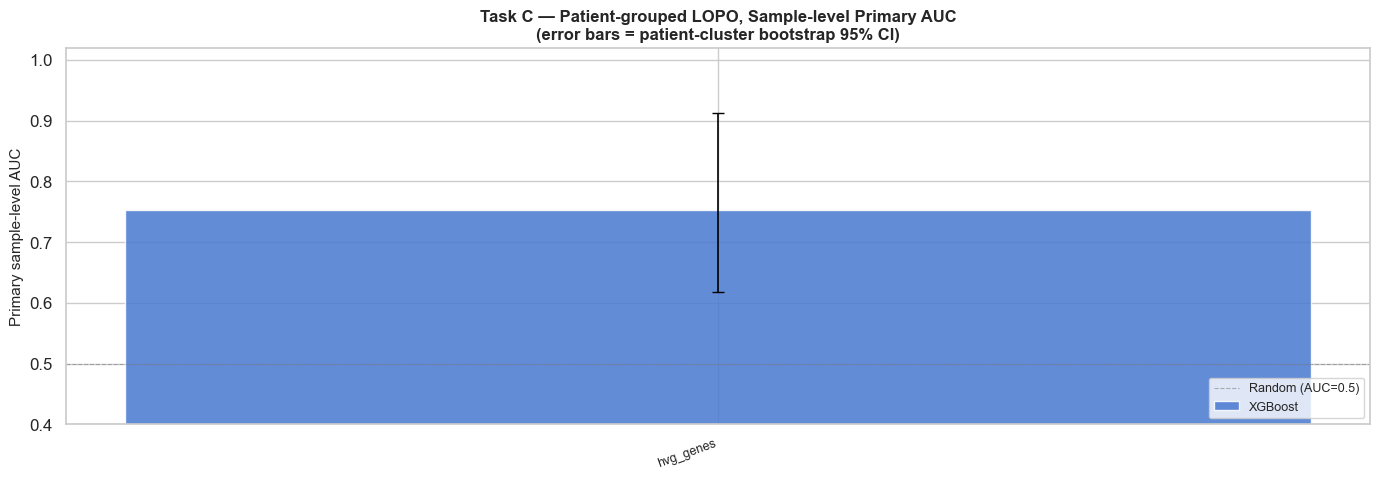

In [ ]:

# Grouped bar chart: primary
fig, ax = plt.subplots(figsize=(14, 5))

feat_order = list(feature_sets.keys())
model_order = MODEL_NAMES
n_feat = len(feat_order)
n_model = len(model_order)
x_base = np.arange(n_feat)
width = 0.24
palette = sns.color_palette("muted", n_model)

for mi, model_name in enumerate(model_order):
    auc_vals, err_lo, err_hi = [], [], []

    for feat_name in feat_order:
        res = ablation_results[(feat_name, model_name)]
        auc = res['boot_mean_auc']
        lo = res['ci_lower']
        hi = res['ci_upper']

        auc_vals.append(auc)
        err_lo.append(max(0, auc - lo))
        err_hi.append(max(0, hi - auc))

    offset = (mi - n_model / 2 + 0.5) * width

    ax.bar(
        x_base + offset,
        auc_vals,
        width,
        label=model_name,
        color=palette[mi],
        alpha=0.85
    )
    ax.errorbar(
        x_base + offset,
        auc_vals,
        yerr=[err_lo, err_hi],
        fmt='none',
        color='black',
        capsize=4,
        linewidth=1.2
    )

ax.set_xticks(x_base)
ax.set_xticklabels(feat_order, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Primary sample-level AUC', fontsize=11)
ax.set_title(
    'Task C — Patient-grouped LOPO, Sample-level Primary AUC\n'
    '(error bars = patient-cluster bootstrap 95% CI)',
    fontsize=12,
    fontweight='bold'
)
ax.set_ylim(0.4, 1.02)
ax.axhline(
    0.5,
    color='grey',
    linestyle='--',
    linewidth=0.8,
    alpha=0.6,
    label='Random (AUC=0.5)'
)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f"{figures_dir}/task_c_ablation_primary_auc.png", dpi=300)
plt.show()


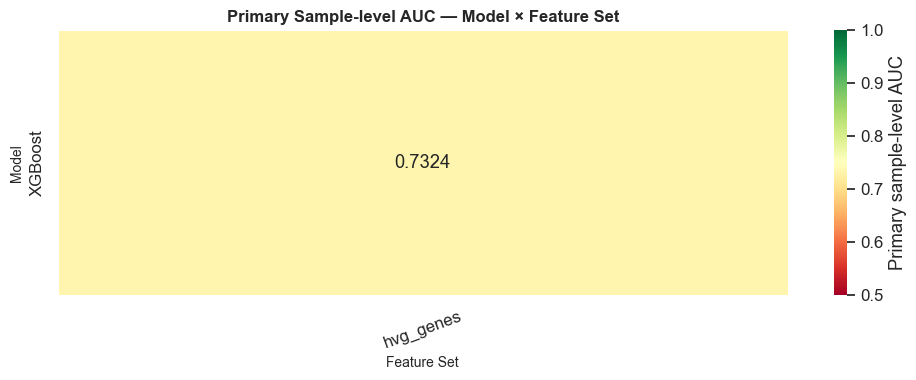

In [ ]:

# Heatmap: primary sample AUC across models × feature sets
heat_data = summary_df.pivot(
    index='Model',
    columns='Feature Set',
    values='Primary Sample AUC (all)'
)[list(feature_sets.keys())]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heat_data,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1.0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Primary sample-level AUC'}
)
ax.set_title(
    'Primary Sample-level AUC — Model × Feature Set',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Feature Set', fontsize=10)
ax.set_ylabel('Model', fontsize=10)
ax.tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.savefig(f'{figures_dir}/primary_sample_auc_heatmap.png', dpi=300)
plt.show()


### Bootstrap distribution (box plots)

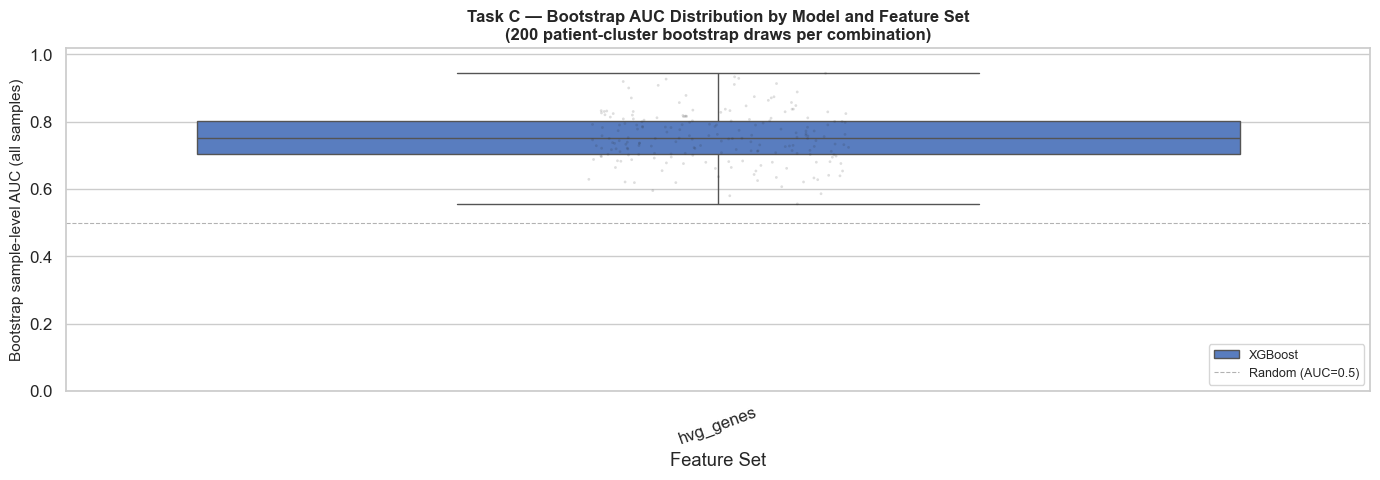

In [ ]:

# Box plot: bootstrap AUC distribution by model and feature set
feat_order = list(feature_sets.keys())
model_order = MODEL_NAMES

box_rows = []
for feat_name in feat_order:
    for model_name in model_order:
        auc_draws = ablation_results[(feat_name, model_name)]['bootstrap']['auc'].values
        for v in auc_draws:
            box_rows.append({
                'Feature Set': feat_name,
                'Model': model_name,
                'Bootstrap AUC': v
            })

box_df = pd.DataFrame(box_rows)

fig, ax = plt.subplots(figsize=(14, 5))

if not box_df.empty:
    sns.boxplot(
        data=box_df,
        x='Feature Set',
        y='Bootstrap AUC',
        hue='Model',
        order=feat_order,
        hue_order=model_order,
        ax=ax,
        showfliers=False,
        palette='muted'
    )
    sns.stripplot(
        data=box_df,
        x='Feature Set',
        y='Bootstrap AUC',
        hue='Model',
        order=feat_order,
        hue_order=model_order,
        ax=ax,
        dodge=True,
        alpha=0.15,
        size=2,
        color='black',
        legend=False
    )

ax.axhline(
    0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
    label='Random (AUC=0.5)'
)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel('Bootstrap sample-level AUC (all samples)', fontsize=11)
ax.set_title(
    'Task C - Bootstrap AUC Distribution by Model and Feature Set\n'
    f'({BOOTSTRAP_ITERS} patient-cluster bootstrap draws per combination)',
    fontsize=12,
    fontweight='bold'
)
ax.tick_params(axis='x', labelrotation=20)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(model_order) + 1], labels[:len(model_order) + 1], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{figures_dir}/task_c_bootstrap_auc_boxplot.png', dpi=300)
plt.show()


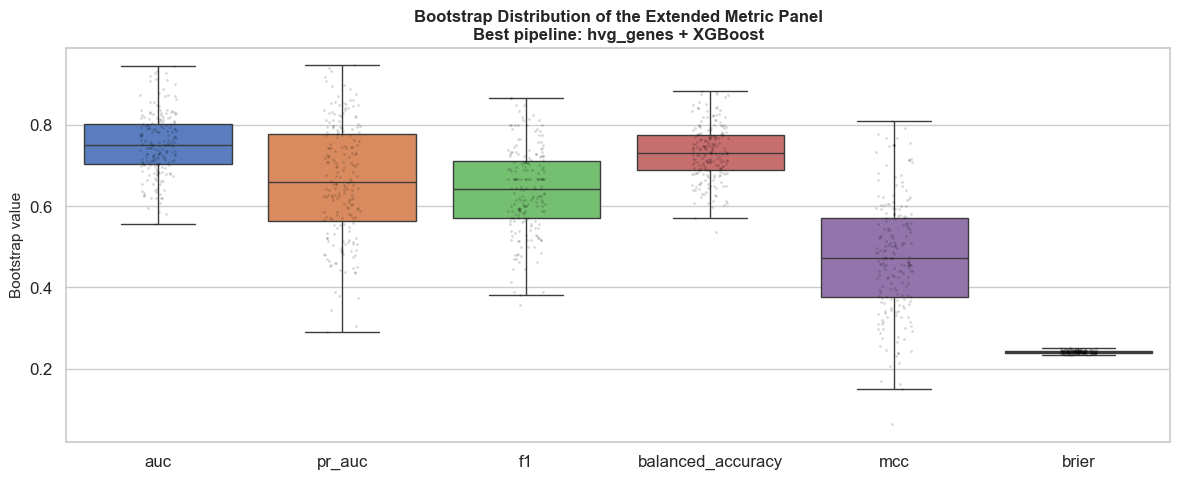

Bootstrap means for the best pipeline:
  auc                mean=0.7527  95% CI [0.6184, 0.9132]
  pr_auc             mean=0.6624  95% CI [0.3880, 0.8983]
  f1                 mean=0.6391  95% CI [0.4437, 0.8238]
  balanced_accuracy  mean=0.7318  95% CI [0.6070, 0.8685]
  mcc                mean=0.4765  95% CI [0.2133, 0.7555]
  brier              mean=0.2418  95% CI [0.2344, 0.2495]


In [ ]:

# Box plot: bootstrap distribution of every metric, best pipeline
best_row = summary_df.sort_values(
    'Primary Sample AUC (all)', ascending=False
).iloc[0]

best_key = (best_row['Feature Set'], best_row['Model'])
best_bootstrap = ablation_results[best_key]['bootstrap']

metric_rows = []
for metric_name, ci in best_bootstrap.items():
    for v in ci.values:
        metric_rows.append({'Metric': metric_name, 'value': v})

metric_df = pd.DataFrame(metric_rows)

fig, ax = plt.subplots(figsize=(12, 5))

if not metric_df.empty:
    sns.boxplot(
        data=metric_df,
        x='Metric',
        y='value',
        hue='Metric',
        order=list(best_bootstrap.keys()),
        ax=ax,
        palette='muted',
        legend=False,
        showfliers=False
    )
    sns.stripplot(
        data=metric_df,
        x='Metric',
        y='value',
        order=list(best_bootstrap.keys()),
        ax=ax,
        color='black',
        alpha=0.15,
        size=2
    )

ax.set_ylabel('Bootstrap value', fontsize=11)
ax.set_xlabel('')
ax.set_title(
    f'Bootstrap Distribution of the Extended Metric Panel\n'
    f'Best pipeline: {best_key[0]} + {best_key[1]}',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{figures_dir}/bootstrap_metrics_{best_key[0]}_{best_key[1]}.png', dpi=300)
plt.show()

print("Bootstrap means for the best pipeline:")
for metric_name, ci in best_bootstrap.items():
    print(f"  {metric_name:18s} mean={ci.mean:.4f}  95% CI [{ci.lower:.4f}, {ci.upper:.4f}]")


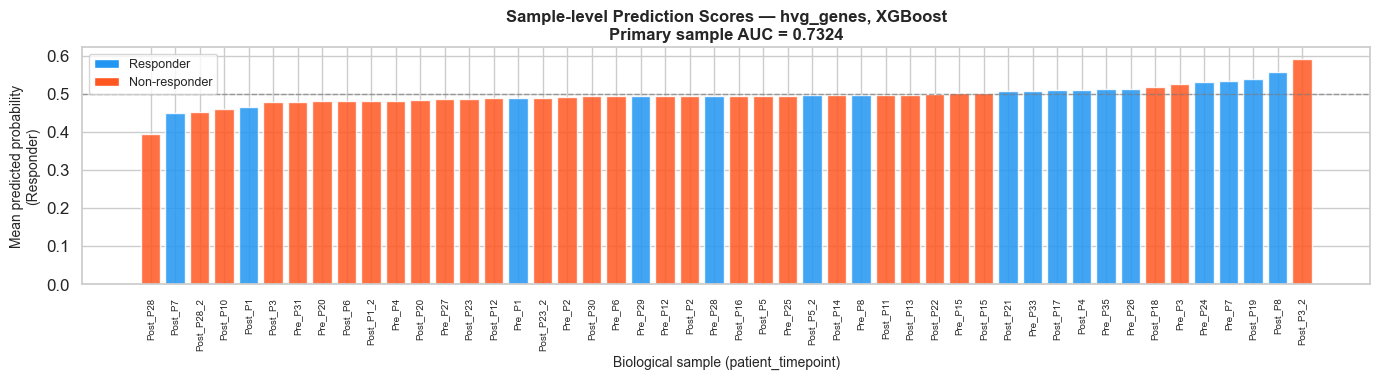

Best feature set: hvg_genes
Best model: XGBoost


In [ ]:

# Biological-sample score plot for the best primary model
best_row = summary_df.sort_values(
    'Primary Sample AUC (all)',
    ascending=False
).iloc[0]

best_model_name = best_row['Model']
best_feature_set = best_row['Feature Set']
best_key = (best_feature_set, best_model_name)
best_results = ablation_results[best_key]['sample_results'].copy()

res_df = best_results.sort_values('sample_score')
res_df['response_label'] = res_df['true_label'].map({
    1: 'Responder',
    0: 'Non-responder'
})

fig, ax = plt.subplots(figsize=(14, 4))
colors = {
    'Responder': '#2196F3',
    'Non-responder': '#FF5722'
}

for _, row in res_df.iterrows():
    ax.bar(
        row['sample_id'],
        row['sample_score'],
        color=colors[row['response_label']],
        alpha=0.85,
        edgecolor='white'
    )

ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Biological sample (patient_timepoint)', fontsize=10)
ax.set_ylabel('Mean predicted probability\n(Responder)', fontsize=10)
ax.set_title(
    f'Sample-level Prediction Scores — {best_feature_set}, '
    f'{best_model_name}\n'
    f'Primary sample AUC = '
    f'{best_row["Primary Sample AUC (all)"]:.4f}',
    fontsize=12,
    fontweight='bold'
)
ax.tick_params(axis='x', labelrotation=90, labelsize=7)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Responder'),
    Patch(facecolor='#FF5722', label='Non-responder')
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(f'{figures_dir}/best_pipeline_sample_scores_{best_feature_set}_{best_model_name}.png', dpi=300)
plt.show()

print(f"Best feature set: {best_feature_set}")
print(f"Best model: {best_model_name}")


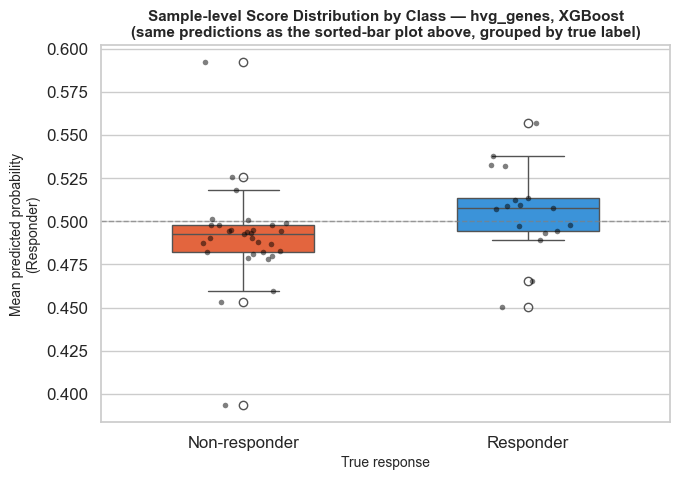

Responder samples     : n=17, median score=0.508
Non-responder samples : n=31, median score=0.493


In [ ]:

# Box plot: sample-level predicted score distribution by true class
res_df = ablation_results[best_key]['sample_results'].copy()
res_df['Response'] = res_df['true_label'].map({1: 'Responder', 0: 'Non-responder'})

class_colors = {'Responder': '#2196F3', 'Non-responder': '#FF5722'}
class_order = ['Non-responder', 'Responder']

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=res_df,
    x='Response',
    y='sample_score',
    hue='Response',
    order=class_order,
    hue_order=class_order,
    ax=ax,
    palette=class_colors,
    legend=False,
    width=0.5
)
sns.stripplot(
    data=res_df,
    x='Response',
    y='sample_score',
    order=class_order,
    ax=ax,
    color='black',
    alpha=0.5,
    size=4,
    jitter=0.15
)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('True response', fontsize=10)
ax.set_ylabel('Mean predicted probability\n(Responder)', fontsize=10)
ax.set_title(
    f'Sample-level Score Distribution by Class — {best_key[0]}, {best_key[1]}\n'
    f'(same predictions as the sorted-bar plot above, grouped by true label)',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f'{figures_dir}/best_pipeline_sample_score_distribution_{best_key[0]}_{best_key[1]}.png', dpi=300)
plt.show()

print(
    f"Responder samples     : n={int((res_df['Response'] == 'Responder').sum())}, "
    f"median score={res_df.loc[res_df['Response'] == 'Responder', 'sample_score'].median():.3f}"
)
print(
    f"Non-responder samples : n={int((res_df['Response'] == 'Non-responder').sum())}, "
    f"median score={res_df.loc[res_df['Response'] == 'Non-responder', 'sample_score'].median():.3f}"
)


---
# 10. Export for Task D

Task D (explainability, error analysis, RL threshold sensitivity, batch correction, external validation) needs to reuse the exact best-performing pipeline from Task C rather than retrain everything from scratch. This section identifies the best `(feature_set, model)` combination and saves a single bundle containing:

- The **fitted model and scaler for every LOPO fold** of the best pipeline (so SHAP can be computed on the exact feature space each model saw).
- The **feature names actually used per fold** (post HVG/MI selection), required to map SHAP values back to gene names.
- The **per-fold best hyperparameters**.
- The **sample-level and patient-level prediction tables**, including which samples were misclassified, their `n_cells`, fold, and mixed-patient status (the direct input to Task D's error analysis).
- The **ablation summary table** for context in the writeup.

This avoids re-running 32-fold Optuna tuning a second time in Task D.

In [ ]:
import pickle

# Identify the best-performing (feature_set, model) pipeline from the ablation.
best_row = summary_df.sort_values('Primary Sample AUC (all)', ascending=False).iloc[0]
best_feature_set = best_row['Feature Set']
best_model_name = best_row['Model']
best_key = (best_feature_set, best_model_name)
best_bundle = ablation_results[best_key]

taskC_export = {
    'best_feature_set': best_feature_set,
    'best_model_name': best_model_name,
    'metrics': {
        'sample_auc_all': best_bundle['sample_auc_all'],
        'sample_auc_nonmixed': best_bundle['sample_auc_nonmixed'],
        'patient_auc_nonmixed': best_bundle['patient_auc_nonmixed'],
        'boot_mean_auc': best_bundle['boot_mean_auc'],
        'ci_lower': best_bundle['ci_lower'],
        'ci_upper': best_bundle['ci_upper'],
    },
    # Extended metric panel (AUC, PR-AUC, F1, balanced accuracy, MCC,
    # Brier, sensitivity, specificity, precision) for each evaluation level,
    # plus the bootstrap distributions behind the box plots above — useful
    # for Task D's report without recomputing anything.
    'metrics_extended': {
        'sample_all': best_bundle['metrics_sample_all'].as_dict(),
        'sample_nonmixed': best_bundle['metrics_sample_nonmixed'].as_dict(),
        'patient_nonmixed': best_bundle['metrics_patient_nonmixed'].as_dict(),
    },
    'bootstrap_distributions': {
        name: {'mean': ci.mean, 'ci_lower': ci.lower, 'ci_upper': ci.upper, 'values': ci.values}
        for name, ci in best_bundle['bootstrap'].items()
    },
    'fold_diagnostics': best_bundle['fold_diagnostics'],
    # Per-fold fitted models, scalers, feature names, hyperparameters, and held-out
    # cell-level predictions — everything needed for SHAP without retraining.
    'fold_artifacts': best_bundle['fold_artifacts'],
    # Sample-level predictions (true_label vs sample_score) for every biological sample,
    # with fold, n_cells, and mixed_patient flags — the direct input to error analysis.
    'sample_results': best_bundle['sample_results'],
    # Patient-level aggregated predictions.
    'patient_results': best_bundle['patient_results'],
    # Full ablation table across all feature sets / models, for context in the report.
    'ablation_summary': summary_df,
    # Static metadata Task D will need to rebuild feature matrices consistently.
    'pathway_cols': pathway_cols,
}

export_path = output_dir / 'taskC_export_for_taskD.pkl'
with open(export_path, 'wb') as f:
    pickle.dump(taskC_export, f)

print(f"Saved Task C → Task D export bundle to: {export_path}")
print(f"Best pipeline: {best_feature_set} + {best_model_name}")
print(f"Sample AUC (all): {best_bundle['sample_auc_all']:.4f}")
m = best_bundle['metrics_sample_all']
print(
    f"Extended (all samples): PR-AUC={m.pr_auc:.4f}  F1={m.f1:.4f}  "
    f"BalAcc={m.balanced_accuracy:.4f}  MCC={m.mcc:.4f}  Brier={m.brier:.4f}"
)
print(f"Folds with saved model/scaler: {len(best_bundle['fold_artifacts'])}")
print(f"Misclassified samples (using 0.5 threshold): "
      f"{((taskC_export['sample_results']['sample_score'] >= 0.5).astype(int) != taskC_export['sample_results']['true_label']).sum()} "
      f"/ {len(taskC_export['sample_results'])}")


Saved Task C → Task D export bundle to: ..\outputs\taskC_export_for_taskD.pkl
Best pipeline: hvg_genes + XGBoost
Sample AUC (all): 0.7324
Extended (all samples): PR-AUC=0.6062  F1=0.6250  BalAcc=0.7135  MCC=0.4405  Brier=0.2424
Folds with saved model/scaler: 32
Misclassified samples (using 0.5 threshold): 12 / 48
